In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(-0.5, 255.5, 0.5, -0.5)

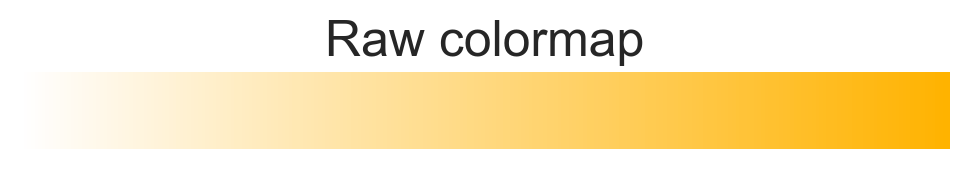

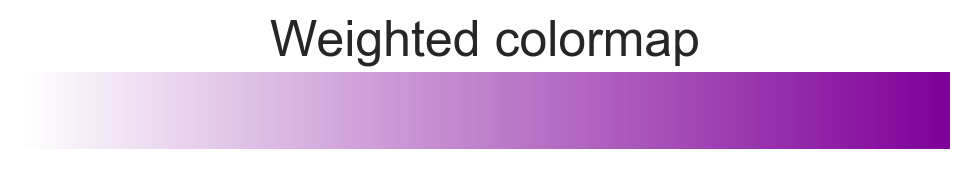

In [3]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "sans-serif",
        "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)


# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [6]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/home/galkepler/Projects/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/home/galkepler/Projects/neuroaging/figures/fig4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [34]:
df = pd.read_csv("BAG_data.csv")

In [35]:
df.filter(regex="ventricle")

,left_lateral_ventricle,third_ventricle,fourth_ventricle,right_lateral_ventricle,fifth_ventricle
0,0.779944,0.108019,0.185045,0.379835,0.000000
1,0.507237,0.090594,0.132896,0.505981,0.000000
2,0.772175,0.063462,0.102638,0.477412,0.000000
3,0.255087,0.038800,0.007531,0.276036,0.000000
4,0.296306,0.069275,0.110490,0.332304,0.000291
...,...,...,...,...,...
2067,0.558380,0.064943,0.045725,0.629632,0.000000
2068,1.076896,0.105793,0.056308,0.917064,0.000000
2069,0.279990,0.050132,0.068851,0.209094,0.000000
2070,0.574655,0.050668,0.028378,0.553614,0.000000


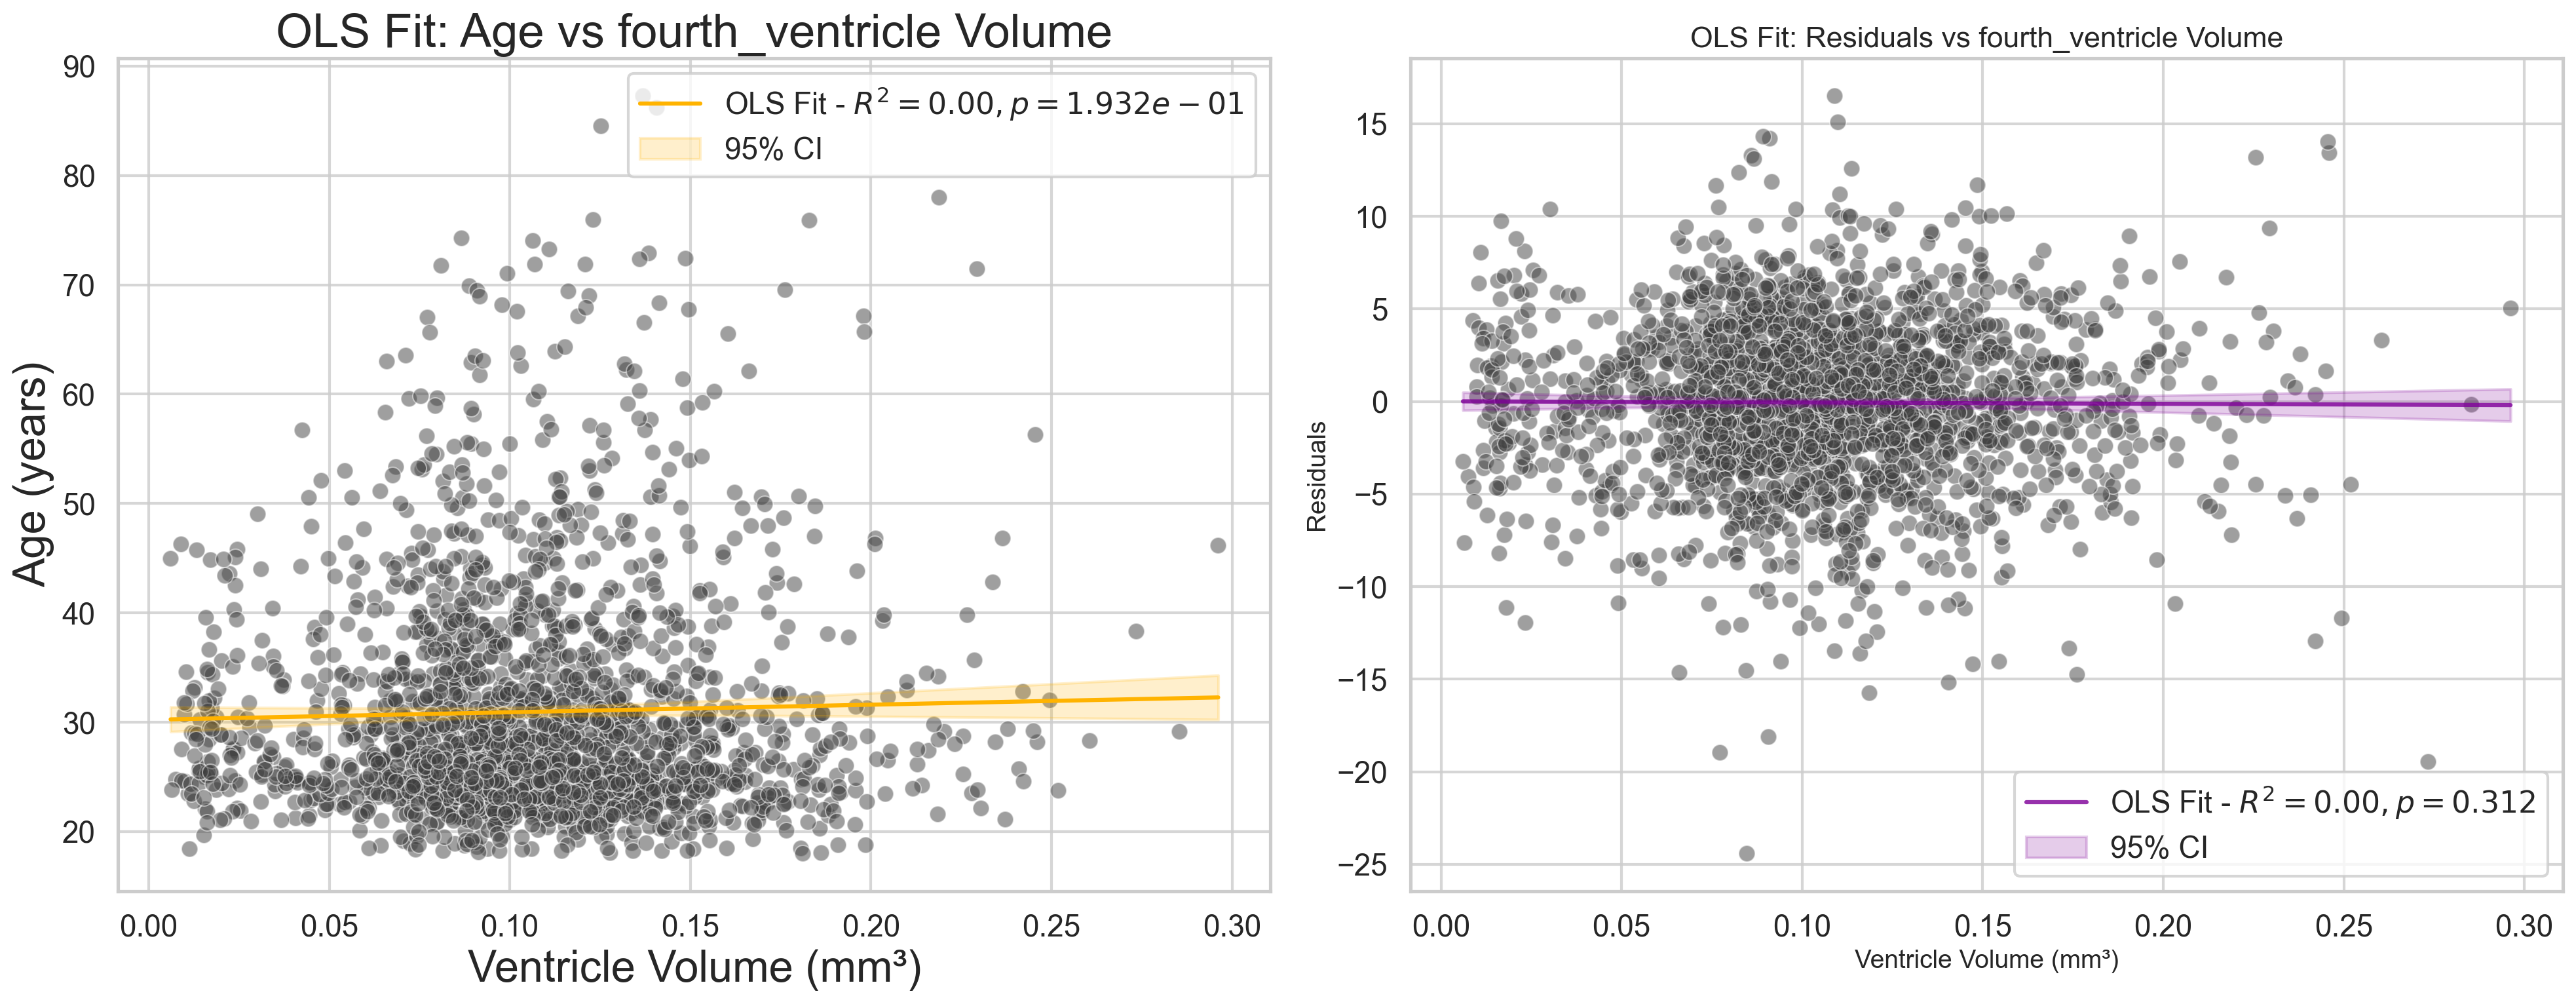

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.utils import resample


metric = "stacked"
col = "fourth_ventricle"

model = ols(f"{metric}_residuals ~ {metric}_age * {col}", data=df).fit()

pred_df = pd.DataFrame({col: np.linspace(df[col].min(), df[col].max(), 100)})
pred_df[f"{metric}_age"] = df[f"{metric}_age"].mean()  # use mean age for prediction

pr = model.get_prediction(pred_df)
ci = pr.conf_int(alpha=0.05)
pred_df["beta_fit"] = pr.predicted_mean
pred_df["beta_lo"] = ci[:, 0]
pred_df["beta_hi"] = ci[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
ax = axes[1]
sns.scatterplot(data=df, x=col, y=f"{metric}_residuals", ax=ax, alpha=0.5, color=COL_REF)
sns.lineplot(
    data=pred_df,
    x=col,
    y="beta_fit",
    ax=ax,
    color=COL_WEIGHTED,
    label=f"OLS Fit - $R^2={model.rsquared:.2f}, p={model.f_pvalue:.3e}$",
)
ax.fill_between(
    pred_df[col],
    pred_df["beta_lo"],
    pred_df["beta_hi"],
    color=COL_WEIGHTED,
    alpha=0.2,
    label="95% CI",
)
ax.set_xlabel("Ventricle Volume (mm³)", fontsize=14)
ax.set_ylabel("Residuals", fontsize=14)
ax.set_title(f"OLS Fit: Residuals vs {col} Volume", fontsize=16)
ax.legend()


ax = axes[0]

model = ols(f"{metric}_age ~  + {col}", data=df).fit()
pred_df = pd.DataFrame({col: np.linspace(df[col].min(), df[col].max(), 100)})
pr = model.get_prediction(pred_df)
ci = pr.conf_int(alpha=0.05)
pred_df["beta_fit"] = pr.predicted_mean
pred_df["beta_lo"] = ci[:, 0]
pred_df["beta_hi"] = ci[:, 1]

sns.scatterplot(data=df, x=col, y=f"{metric}_age", ax=ax, alpha=0.5, color=COL_REF)
sns.lineplot(
    data=pred_df,
    x=col,
    y="beta_fit",
    ax=ax,
    color=COL_RAW,
    label=f"OLS Fit - $R^2={model.rsquared:.2f}, p={model.f_pvalue:.3e}$",
)
ax.fill_between(
    pred_df[col],
    pred_df["beta_lo"],
    pred_df["beta_hi"],
    color=COL_RAW,
    alpha=0.2,
    label="95% CI",
)
ax.set_xlabel("Ventricle Volume (mm³)", fontsize=24)
ax.set_ylabel("Age (years)", fontsize=24)
ax.set_title(f"OLS Fit: Age vs {col} Volume", fontsize=26)
ax.legend()


plt.tight_layout()
plt.show()